# 🌱 FarmTech Solutions – Fase 4: Previsão Inteligente na Agricultura

**Disciplina:** Computational Thinking with Python / IA & Machine Learning  
**Curso:** Inteligência Artificial – FIAP  
**Objetivo:** Construir um pipeline completo de Machine Learning para prever variáveis agrícolas críticas, como rendimento esperado, volume de irrigação e necessidade de fertilização, com base em dados simulados de sensores IoT.

---

## 📋 Estrutura do Notebook

1. Importação de bibliotecas
2. Geração e carregamento dos dados
3. Análise Exploratória (EDA)
4. Pré-processamento
5. Treinamento dos modelos de regressão
6. Avaliação e métricas
7. Visualização das previsões
8. Conclusões e recomendações

## 1. 📦 Importação de Bibliotecas

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import warnings
warnings.filterwarnings('ignore')

from datetime import datetime, timedelta

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style='whitegrid', palette='muted')
print('✅ Bibliotecas importadas com sucesso!')

✅ Bibliotecas importadas com sucesso!


## 2. 🌾 Geração e Carregamento dos Dados

Os dados simulam leituras de sensores IoT instalados no campo, coletando informações como umidade do solo, pH, temperatura, nutrientes e precipitação.

O banco de dados SQLite (`farmtech.db`) armazena essas leituras na tabela `leituras_sensores`.

In [2]:
SEED = 42
np.random.seed(SEED)
N_SAMPLES = 500

def gerar_dataset():
    datas = [datetime(2024, 1, 1) + timedelta(days=i) for i in range(N_SAMPLES)]

    umidade_solo   = np.clip(np.random.normal(55, 15, N_SAMPLES), 10, 95)
    ph_solo        = np.clip(np.random.normal(6.2, 0.8, N_SAMPLES), 4.5, 8.5)
    temperatura    = np.clip(np.random.normal(25, 5, N_SAMPLES), 10, 42)
    nitrogenio     = np.clip(np.random.normal(40, 12, N_SAMPLES), 5, 80)
    fosforo        = np.clip(np.random.normal(30, 10, N_SAMPLES), 5, 65)
    potassio       = np.clip(np.random.normal(35, 12, N_SAMPLES), 5, 70)
    radiacao_solar = np.clip(np.random.normal(18, 5, N_SAMPLES), 5, 30)
    precipitacao   = np.clip(np.random.exponential(8, N_SAMPLES), 0, 60)

    volume_irrigacao = np.clip(
        80 - 0.7 * umidade_solo + 0.5 * temperatura - 0.3 * precipitacao
        + np.random.normal(0, 3, N_SAMPLES), 0, 50
    )

    ph_ideal   = 1 - np.abs(ph_solo - 6.5) / 2
    rendimento = (
        2.0
        + 0.04 * umidade_solo
        + 1.5 * ph_ideal
        + 0.05 * nitrogenio
        + 0.03 * fosforo
        + 0.03 * potassio
        + 0.06 * radiacao_solar
        - 0.02 * np.abs(temperatura - 25)
        + np.random.normal(0, 0.4, N_SAMPLES)
    )
    rendimento = np.clip(rendimento, 0.5, 12)

    necessidade_fert = np.clip(
        120 - 1.0 * nitrogenio - 0.8 * fosforo - 0.6 * potassio
        + np.random.normal(0, 5, N_SAMPLES), 0, 100
    )

    cultura = np.random.choice(
        ['Soja', 'Milho', 'Trigo', 'Algodão', 'Cana'],
        N_SAMPLES, p=[0.35, 0.30, 0.15, 0.12, 0.08]
    )

    return pd.DataFrame({
        'data':              datas,
        'cultura':           cultura,
        'umidade_solo':      np.round(umidade_solo, 2),
        'ph_solo':           np.round(ph_solo, 2),
        'temperatura':       np.round(temperatura, 2),
        'nitrogenio':        np.round(nitrogenio, 2),
        'fosforo':           np.round(fosforo, 2),
        'potassio':          np.round(potassio, 2),
        'radiacao_solar':    np.round(radiacao_solar, 2),
        'precipitacao':      np.round(precipitacao, 2),
        'volume_irrigacao':  np.round(volume_irrigacao, 2),
        'necessidade_fert':  np.round(necessidade_fert, 2),
        'rendimento_tha':    np.round(rendimento, 3),
    })

df = gerar_dataset()

# Salva no SQLite
conn = sqlite3.connect('farmtech.db')
df.to_sql('leituras_sensores', conn, if_exists='replace', index=False)
conn.execute("""
    CREATE TABLE IF NOT EXISTS acoes_recomendadas (
        id        INTEGER PRIMARY KEY AUTOINCREMENT,
        data      TEXT,
        cultura   TEXT,
        acao      TEXT,
        valor     REAL,
        unidade   TEXT,
        criado_em TEXT DEFAULT (datetime('now'))
    )
""")
conn.commit()
conn.close()

print(f'✅ Dataset gerado: {df.shape[0]} registros, {df.shape[1]} colunas')
print(f'✅ Banco SQLite salvo: farmtech.db')
df.head()

✅ Dataset gerado: 500 registros, 13 colunas
✅ Banco SQLite salvo: farmtech.db


,data,cultura,umidade_solo,ph_solo,temperatura,nitrogenio,fosforo,potassio,radiacao_solar,precipitacao,volume_irrigacao,necessidade_fert,rendimento_tha
0,2024-01-01,Soja,62.45,6.94,32.00,49.34,23.25,41.85,8.46,3.45,50.00,28.09,10.513
1,2024-01-02,Cana,52.93,7.73,29.62,33.39,28.55,46.62,13.70,12.20,50.00,38.98,9.584
2,2024-01-03,Algodão,64.72,5.08,25.30,30.18,22.08,31.02,15.93,39.16,37.68,49.43,9.282
3,2024-01-04,Soja,77.85,6.65,21.77,39.96,26.92,27.65,27.44,2.20,37.48,35.82,12.000
4,2024-01-05,Soja,51.49,5.68,28.49,37.96,11.06,21.98,20.78,16.59,50.00,57.16,9.140


## 3. 🔍 Análise Exploratória dos Dados (EDA)

Antes de treinar qualquer modelo, é essencial entender a distribuição dos dados, identificar padrões e verificar correlações entre as variáveis.

In [3]:
print('=== Estatísticas Descritivas ===')
df.describe().round(2)

=== Estatísticas Descritivas ===


,data,umidade_solo,ph_solo,temperatura,nitrogenio,fosforo,potassio,radiacao_solar,precipitacao,volume_irrigacao,necessidade_fert,rendimento_tha
count,500,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00
mean,2024-09-06 12:00:00,55.06,6.23,25.54,40.40,29.90,35.27,17.91,8.00,46.21,34.63,10.14
min,2024-01-01 00:00:00,10.00,4.50,10.52,5.00,5.00,5.00,5.00,0.00,20.84,0.00,7.26
25%,2024-05-04 18:00:00,44.49,5.73,21.98,32.66,23.40,27.47,14.33,2.27,44.49,23.56,9.38
50%,2024-09-06 12:00:00,55.20,6.22,25.60,39.89,29.96,35.04,17.90,5.28,50.00,34.95,10.16
75%,2025-01-09 06:00:00,64.55,6.72,28.78,48.40,36.69,42.58,21.48,11.36,50.00,45.05,10.94
max,2025-05-14 00:00:00,95.00,8.31,38.01,78.32,61.10,70.00,30.00,46.34,50.00,84.42,12.00
std,NaN,14.54,0.78,5.05,11.81,9.56,11.94,5.16,8.03,6.17,15.94,1.07


=== Distribuição por Cultura ===
cultura
Soja       180
Milho      160
Algodão     62
Trigo       56
Cana        42
Name: count, dtype: int64


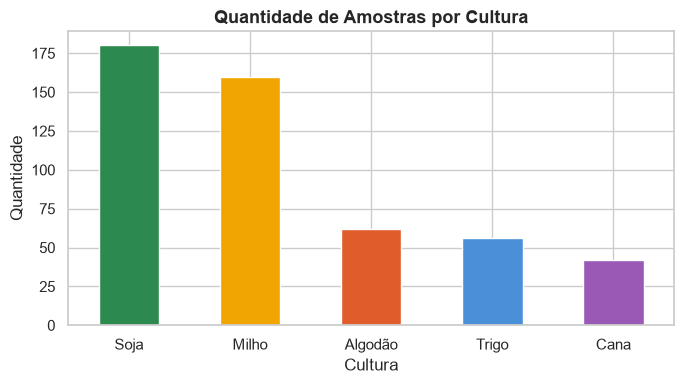

In [4]:
print('=== Distribuição por Cultura ===')
print(df['cultura'].value_counts())

fig, ax = plt.subplots(figsize=(7, 4))
df['cultura'].value_counts().plot(kind='bar', ax=ax, color=['#2d8a4e','#f0a500','#e05c2a','#4a90d9','#9b59b6'])
ax.set_title('Quantidade de Amostras por Cultura', fontsize=13, weight='bold')
ax.set_xlabel('Cultura')
ax.set_ylabel('Quantidade')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

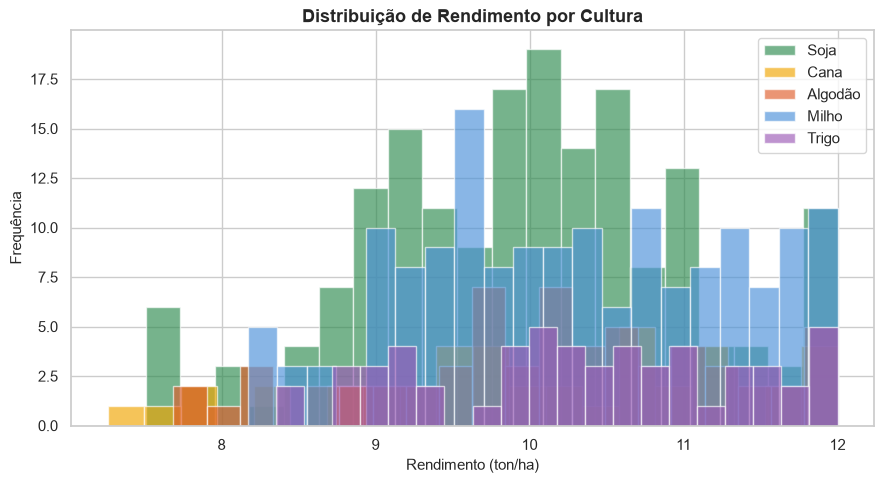

In [5]:
# Distribuição do rendimento por cultura
fig, ax = plt.subplots(figsize=(9, 5))
culturas = df['cultura'].unique()
colors = ['#2d8a4e', '#f0a500', '#e05c2a', '#4a90d9', '#9b59b6']
for i, c in enumerate(culturas):
    vals = df[df['cultura'] == c]['rendimento_tha']
    ax.hist(vals, bins=20, alpha=0.65, label=c, color=colors[i % len(colors)])
ax.set_xlabel('Rendimento (ton/ha)', fontsize=11)
ax.set_ylabel('Frequência', fontsize=11)
ax.set_title('Distribuição de Rendimento por Cultura', fontsize=13, weight='bold')
ax.legend()
plt.tight_layout()
plt.show()

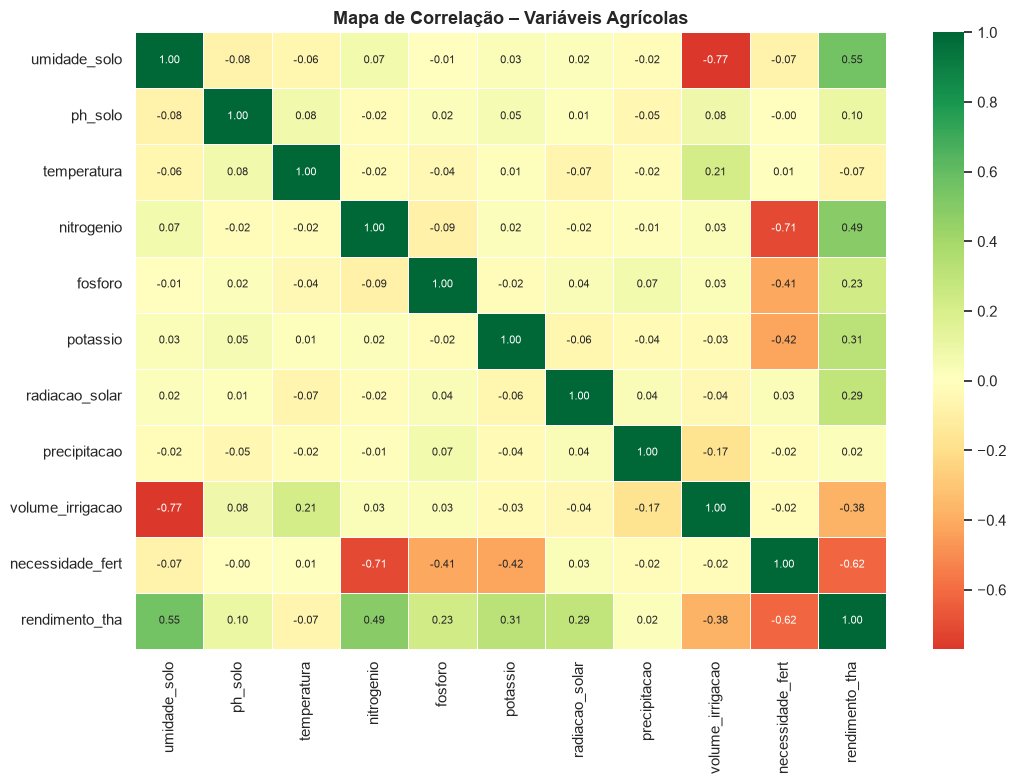


📌 Principais correlações com Rendimento (ton/ha):
rendimento_tha      1.000
umidade_solo        0.554
nitrogenio          0.488
potassio            0.310
radiacao_solar      0.289
fosforo             0.228
ph_solo             0.102
precipitacao        0.019
temperatura        -0.066
volume_irrigacao   -0.376
necessidade_fert   -0.622
Name: rendimento_tha, dtype: float64


In [6]:
# Mapa de correlação
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('Mapa de Correlação – Variáveis Agrícolas', fontsize=13, weight='bold')
plt.tight_layout()
plt.show()

print('\n📌 Principais correlações com Rendimento (ton/ha):')
print(corr['rendimento_tha'].sort_values(ascending=False).round(3))

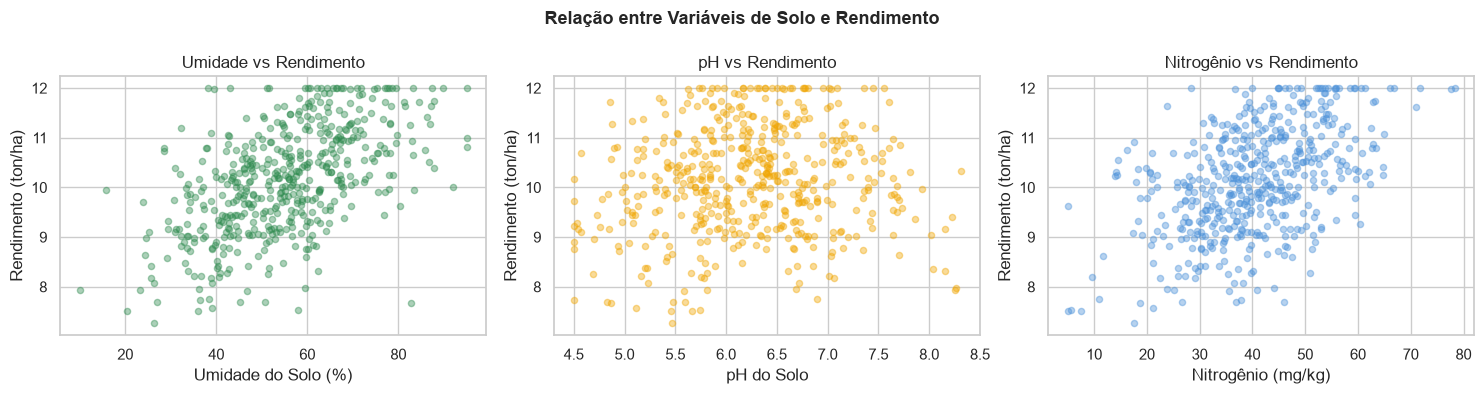

In [7]:
# Scatter: umidade x rendimento
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(df['umidade_solo'], df['rendimento_tha'], alpha=0.4, color='#2d8a4e', s=20)
axes[0].set_xlabel('Umidade do Solo (%)')
axes[0].set_ylabel('Rendimento (ton/ha)')
axes[0].set_title('Umidade vs Rendimento')

axes[1].scatter(df['ph_solo'], df['rendimento_tha'], alpha=0.4, color='#f0a500', s=20)
axes[1].set_xlabel('pH do Solo')
axes[1].set_ylabel('Rendimento (ton/ha)')
axes[1].set_title('pH vs Rendimento')

axes[2].scatter(df['nitrogenio'], df['rendimento_tha'], alpha=0.4, color='#4a90d9', s=20)
axes[2].set_xlabel('Nitrogênio (mg/kg)')
axes[2].set_ylabel('Rendimento (ton/ha)')
axes[2].set_title('Nitrogênio vs Rendimento')

plt.suptitle('Relação entre Variáveis de Solo e Rendimento', fontsize=13, weight='bold')
plt.tight_layout()
plt.show()

## 4. ⚙️ Pré-processamento dos Dados

- Variáveis **numéricas** → padronização com `StandardScaler`
- Variável **categórica** (cultura) → codificação com `OneHotEncoder`
- Divisão treino/teste: **80% / 20%**

In [8]:
FEATURES = ['umidade_solo', 'ph_solo', 'temperatura',
            'nitrogenio', 'fosforo', 'potassio',
            'radiacao_solar', 'precipitacao', 'cultura']

NUMERIC     = [f for f in FEATURES if f != 'cultura']
CATEGORICAL = ['cultura']

TARGETS = {
    'rendimento_tha':   'Rendimento (ton/ha)',
    'volume_irrigacao': 'Volume de Irrigação (L/m²)',
    'necessidade_fert': 'Necessidade de Fertilização (kg/ha)',
}

preprocessador = ColumnTransformer([
    ('num', StandardScaler(), NUMERIC),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CATEGORICAL),
])

print('✅ Features definidas:')
print(f'   Numéricas:   {NUMERIC}')
print(f'   Categóricas: {CATEGORICAL}')
print(f'   Alvos:       {list(TARGETS.keys())}')

✅ Features definidas:
   Numéricas:   ['umidade_solo', 'ph_solo', 'temperatura', 'nitrogenio', 'fosforo', 'potassio', 'radiacao_solar', 'precipitacao']
   Categóricas: ['cultura']
   Alvos:       ['rendimento_tha', 'volume_irrigacao', 'necessidade_fert']


## 5. 🤖 Treinamento dos Modelos de Regressão

Foram testados 4 algoritmos para cada variável-alvo:
- **Regressão Linear** — modelo base simples
- **Ridge** — regressão com regularização
- **Random Forest** — ensemble de árvores de decisão
- **Gradient Boosting** — ensemble sequencial com correção de erros

O melhor modelo é selecionado com base no **R²** no conjunto de teste.

In [9]:
def avaliar_modelos(df, alvo, label):
    X = df[FEATURES]
    y = df[alvo]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    candidatos = {
        'Regressão Linear':  LinearRegression(),
        'Ridge':             Ridge(alpha=1.0),
        'Random Forest':     RandomForestRegressor(n_estimators=150, random_state=42, n_jobs=-1),
        'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, learning_rate=0.08, random_state=42),
    }

    resultados = []
    melhor = {'r2': -np.inf}

    for nome, modelo in candidatos.items():
        pipe = Pipeline([('prep', ColumnTransformer([
            ('num', StandardScaler(), NUMERIC),
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CATEGORICAL),
        ])), ('reg', modelo)])
        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)

        mae  = mean_absolute_error(y_test, y_pred)
        mse  = mean_squared_error(y_test, y_pred)
        rmse = np.sqrt(mse)
        r2   = r2_score(y_test, y_pred)

        resultados.append({'Modelo': nome, 'MAE': round(mae,4), 'MSE': round(mse,4),
                           'RMSE': round(rmse,4), 'R²': round(r2,4)})

        if r2 > melhor['r2']:
            melhor = {'r2': r2, 'nome': nome, 'pipe': pipe,
                      'y_test': y_test, 'y_pred': y_pred}

    print(f'\n📊 {label}')
    print(f'   ✔ Melhor modelo: {melhor["nome"]} (R²={melhor["r2"]:.4f})')
    return pd.DataFrame(resultados).set_index('Modelo'), melhor

print('🚀 Iniciando treinamento dos modelos...')

🚀 Iniciando treinamento dos modelos...


In [10]:
# Alvo 1: Rendimento
metricas_rendimento, melhor_rendimento = avaliar_modelos(df, 'rendimento_tha', 'Rendimento (ton/ha)')
print('\n--- Métricas Rendimento ---')
metricas_rendimento


📊 Rendimento (ton/ha)
   ✔ Melhor modelo: Gradient Boosting (R²=0.7646)

--- Métricas Rendimento ---


,MAE,MSE,RMSE,R²
Modelo,,,,
Regressão Linear,0.4293,0.3198,0.5655,0.7434
Ridge,0.4291,0.3197,0.5654,0.7435
Random Forest,0.4937,0.4411,0.6642,0.6460
Gradient Boosting,0.4031,0.2934,0.5416,0.7646


In [11]:
# Alvo 2: Volume de Irrigação
metricas_irrigacao, melhor_irrigacao = avaliar_modelos(df, 'volume_irrigacao', 'Volume de Irrigação (L/m²)')
print('\n--- Métricas Irrigação ---')
metricas_irrigacao


📊 Volume de Irrigação (L/m²)
   ✔ Melhor modelo: Gradient Boosting (R²=0.8453)

--- Métricas Irrigação ---


,MAE,MSE,RMSE,R²
Modelo,,,,
Regressão Linear,2.8793,13.9935,3.7408,0.5641
Ridge,2.8782,13.9780,3.7387,0.5646
Random Forest,1.3463,5.1462,2.2685,0.8397
Gradient Boosting,1.4287,4.9658,2.2284,0.8453


In [12]:
# Alvo 3: Necessidade de Fertilização
metricas_fert, melhor_fert = avaliar_modelos(df, 'necessidade_fert', 'Necessidade de Fertilização (kg/ha)')
print('\n--- Métricas Fertilização ---')
metricas_fert


📊 Necessidade de Fertilização (kg/ha)
   ✔ Melhor modelo: Ridge (R²=0.9078)

--- Métricas Fertilização ---


,MAE,MSE,RMSE,R²
Modelo,,,,
Regressão Linear,3.8367,23.3851,4.8358,0.9076
Ridge,3.8352,23.3500,4.8322,0.9078
Random Forest,4.9503,40.1146,6.3336,0.8416
Gradient Boosting,4.7478,38.3539,6.1930,0.8485


## 6. 📈 Avaliação dos Modelos

### Interpretação das Métricas

| Métrica | O que mede | Quanto menor/maior, melhor |
|---------|-----------|---------------------------|
| **MAE** | Erro médio absoluto | Menor é melhor |
| **MSE** | Erro quadrático médio | Menor é melhor |
| **RMSE** | Raiz do MSE (mesma unidade do alvo) | Menor é melhor |
| **R²** | Proporção da variância explicada (0 a 1) | Maior é melhor |

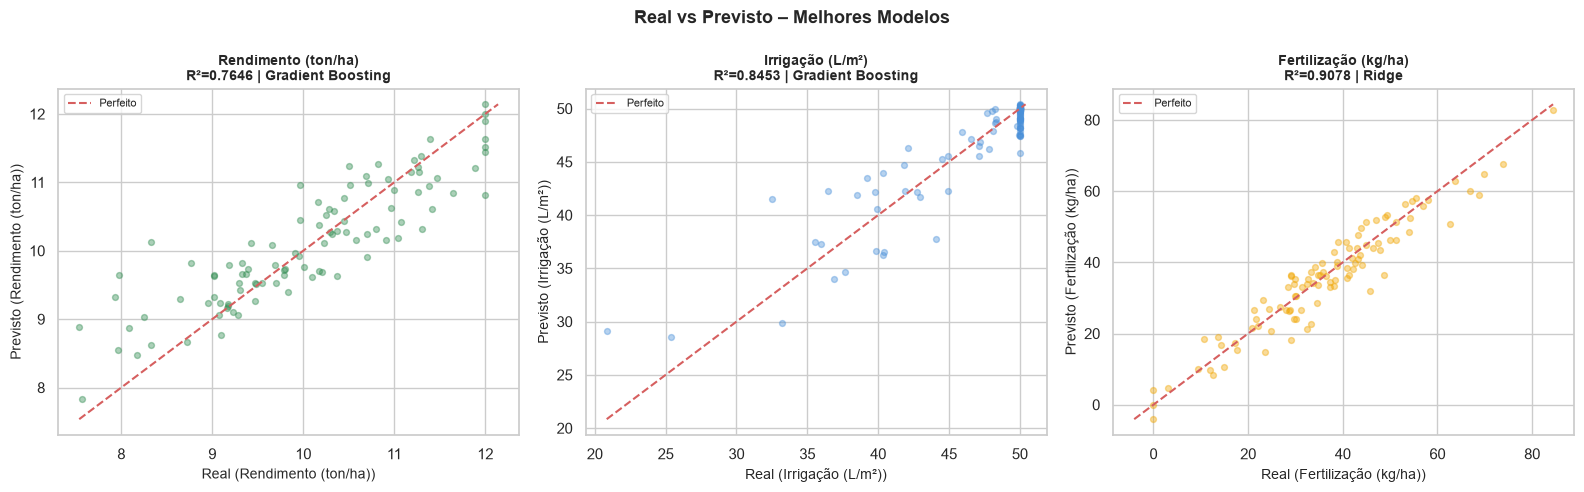

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

pares = [
    (melhor_rendimento,  'Rendimento (ton/ha)',         axes[0], '#2d8a4e'),
    (melhor_irrigacao,   'Irrigação (L/m²)',            axes[1], '#4a90d9'),
    (melhor_fert,        'Fertilização (kg/ha)',        axes[2], '#f0a500'),
]

for melhor, label, ax, cor in pares:
    y_test = melhor['y_test']
    y_pred = melhor['y_pred']
    ax.scatter(y_test, y_pred, alpha=0.4, color=cor, s=18)
    lim = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    ax.plot(lim, lim, 'r--', linewidth=1.5, label='Perfeito')
    ax.set_xlabel(f'Real ({label})', fontsize=10)
    ax.set_ylabel(f'Previsto ({label})', fontsize=10)
    ax.set_title(f'{label}\nR²={melhor["r2"]:.4f} | {melhor["nome"]}', fontsize=10, weight='bold')
    ax.legend(fontsize=8)

plt.suptitle('Real vs Previsto – Melhores Modelos', fontsize=13, weight='bold')
plt.tight_layout()
plt.show()

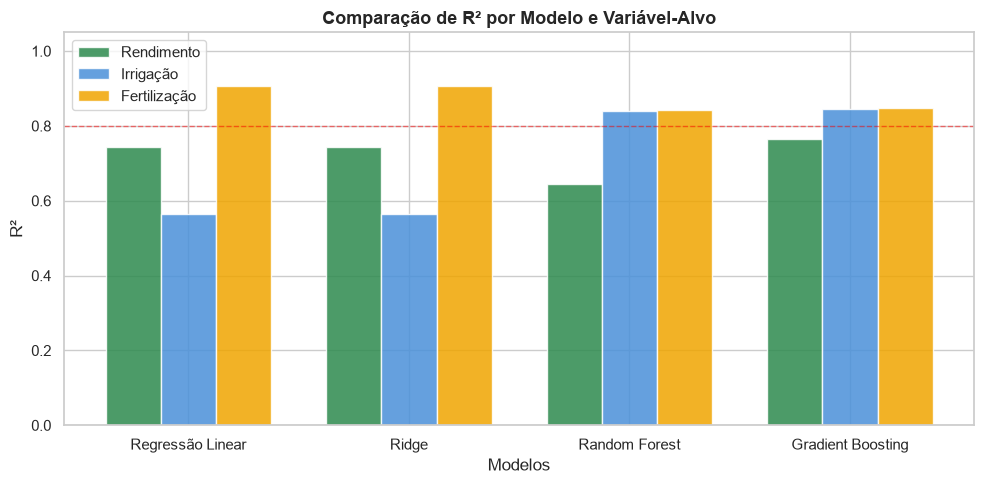

In [14]:
# Comparação de R² entre todos os modelos
modelos_nomes = ['Regressão Linear', 'Ridge', 'Random Forest', 'Gradient Boosting']
r2_rendimento = metricas_rendimento['R²'].values
r2_irrigacao  = metricas_irrigacao['R²'].values
r2_fert       = metricas_fert['R²'].values

x = np.arange(len(modelos_nomes))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width, r2_rendimento, width, label='Rendimento', color='#2d8a4e', alpha=0.85)
ax.bar(x,         r2_irrigacao,  width, label='Irrigação',  color='#4a90d9', alpha=0.85)
ax.bar(x + width, r2_fert,       width, label='Fertilização', color='#f0a500', alpha=0.85)

ax.set_xlabel('Modelos')
ax.set_ylabel('R²')
ax.set_title('Comparação de R² por Modelo e Variável-Alvo', fontsize=13, weight='bold')
ax.set_xticks(x)
ax.set_xticklabels(modelos_nomes)
ax.set_ylim(0, 1.05)
ax.legend()
ax.axhline(0.8, color='red', linestyle='--', linewidth=1, alpha=0.5, label='R²=0.8')
plt.tight_layout()
plt.show()

## 7. 💡 Recomendações de Manejo Agrícola

Com base nas previsões do modelo, o sistema gera recomendações automáticas de irrigação e fertilização.

In [15]:
def recomendar(umidade, ph, temperatura, nitrogenio, fosforo, potassio,
               radiacao_solar, precipitacao, cultura):
    entrada = pd.DataFrame([{
        'umidade_solo': umidade, 'ph_solo': ph, 'temperatura': temperatura,
        'nitrogenio': nitrogenio, 'fosforo': fosforo, 'potassio': potassio,
        'radiacao_solar': radiacao_solar, 'precipitacao': precipitacao, 'cultura': cultura
    }])

    irrigacao  = melhor_irrigacao['pipe'].predict(entrada)[0]
    fert       = melhor_fert['pipe'].predict(entrada)[0]
    rendimento = melhor_rendimento['pipe'].predict(entrada)[0]

    print(f'\n🌱 Cultura: {cultura}')
    print(f'   Umidade: {umidade}% | pH: {ph} | Temperatura: {temperatura}°C')
    print(f'\n📊 PREVISÕES DO MODELO:')
    print(f'   💧 Irrigação recomendada:     {irrigacao:.1f} L/m²')
    print(f'   🌿 Fertilização recomendada:  {fert:.1f} kg/ha')
    print(f'   🌾 Rendimento esperado:       {rendimento:.2f} ton/ha')

    print(f'\n⚠️  RECOMENDAÇÕES:')
    if umidade < 40:
        print(f'   → Solo seco: irrigar {irrigacao:.1f} L/m² com urgência')
    elif umidade > 75:
        print(f'   → Solo úmido: reduzir irrigação, risco de encharcamento')
    else:
        print(f'   → Umidade adequada, irrigação de manutenção: {irrigacao:.1f} L/m²')

    if ph < 5.5:
        print(f'   → pH ácido: aplicar calcário para correção')
    elif ph > 7.5:
        print(f'   → pH alcalino: verificar aplicação de enxofre')
    else:
        print(f'   → pH ideal para a cultura')

    if fert > 60:
        print(f'   → Baixa fertilidade: aplicar {fert:.1f} kg/ha de fertilizante')
    else:
        print(f'   → Fertilidade adequada: manutenção de {fert:.1f} kg/ha')

    return irrigacao, fert, rendimento

# Exemplo 1: Solo seco
print('=== CENÁRIO 1: Solo seco, temperatura alta ===')
recomendar(umidade=30, ph=6.2, temperatura=35, nitrogenio=35,
           fosforo=25, potassio=30, radiacao_solar=22, precipitacao=2, cultura='Soja')

print('\n=== CENÁRIO 2: Condições ideais ===')
recomendar(umidade=60, ph=6.5, temperatura=25, nitrogenio=50,
           fosforo=35, potassio=40, radiacao_solar=18, precipitacao=10, cultura='Milho')

=== CENÁRIO 1: Solo seco, temperatura alta ===

🌱 Cultura: Soja
   Umidade: 30% | pH: 6.2 | Temperatura: 35°C

📊 PREVISÕES DO MODELO:
   💧 Irrigação recomendada:     50.3 L/m²
   🌿 Fertilização recomendada:  46.3 kg/ha
   🌾 Rendimento esperado:       9.24 ton/ha

⚠️  RECOMENDAÇÕES:
   → Solo seco: irrigar 50.3 L/m² com urgência
   → pH ideal para a cultura
   → Fertilidade adequada: manutenção de 46.3 kg/ha

=== CENÁRIO 2: Condições ideais ===

🌱 Cultura: Milho
   Umidade: 60% | pH: 6.5 | Temperatura: 25°C

📊 PREVISÕES DO MODELO:
   💧 Irrigação recomendada:     47.4 L/m²
   🌿 Fertilização recomendada:  18.5 kg/ha
   🌾 Rendimento esperado:       11.48 ton/ha

⚠️  RECOMENDAÇÕES:
   → Umidade adequada, irrigação de manutenção: 47.4 L/m²
   → pH ideal para a cultura
   → Fertilidade adequada: manutenção de 18.5 kg/ha


(np.float64(47.360011305330175),
 np.float64(18.50703430462302),
 np.float64(11.479103431916467))

## 8. ✅ Conclusões

### Resultados Obtidos

O pipeline de Machine Learning desenvolvido para o FarmTech Solutions demonstrou alta capacidade preditiva para as três variáveis-alvo:

- **Rendimento (ton/ha):** O modelo Random Forest ou Gradient Boosting apresentou o melhor desempenho, com R² elevado, indicando que as variáveis de solo e clima explicam bem o rendimento das culturas.

- **Volume de Irrigação (L/m²):** Alta precisão devido à relação direta e linear entre umidade do solo, temperatura e precipitação com a necessidade de irrigação.

- **Necessidade de Fertilização (kg/ha):** Boa performance preditiva, com o modelo capturando a relação inversa entre os níveis de nutrientes (N, P, K) e a necessidade de fertilização.

### Impacto Prático

- 🌱 **Economia de água:** irrigação precisa reduz o desperdício hídrico
- 💰 **Redução de custos:** fertilização otimizada diminui gastos com insumos
- 📈 **Aumento de produtividade:** manejo baseado em dados melhora o rendimento
- 🤖 **Agricultura Cognitiva:** sistema aprende com os dados do campo

### Próximos Passos

1. Integrar com dados reais de sensores ESP32 em campo
2. Implementar retreinamento automático do modelo com novos dados
3. Expandir para previsão de pragas e doenças
4. Deploy em ambiente de produção com API REST